# Uplift Modeling & Bayesian Causal Inference (MCMC)
## Step 3: Counterfactual Uplift, Downside Risk & Decision-Theoretic ROI

---

### Executive Overview
In **Step 2**, we trained a Bayesian logistic regression model via MCMC (NUTS), obtaining the posterior distributions for treatment intercepts $\boldsymbol{\alpha}$ and confounder coefficients $\boldsymbol{\beta}$.

In this final notebook, we translate those abstract statistical parameters into actionable commercial decisions:
> *"Which promotional campaign should we launch, how many incremental conversions will it deliver, and what is the financial risk of losing money after accounting for cannibalization and contact costs?"*

---

### Methodological Pillars

#### 1. Counterfactual Population Simulation (G-Computation)
Traditional predictive models only estimate $P(Y=1 \mid X, T)$, which conflates customer predisposition with promotional impact. Here, we implement **Robins' G-Computation** (causal standardization):
- For each posterior MCMC draw $t \in \{1, \dots, S\}$, we ask: *"What would the entire population's conversion rate be if everyone received treatment $T = a$?"*
- This yields the population-averaged causal expectation $\mathbb{E}[Y \mid \text{do}(T = a)]$ for each treatment arm:
  $$
  p_{\text{No Offer}}^{(t)} = \frac{1}{N} \sum_{i=1}^N \sigma(\alpha_0^{(t)} + X_i\beta^{(t)}), \quad
  p_{\text{BOGO}}^{(t)} = \frac{1}{N} \sum_{i=1}^N \sigma(\alpha_1^{(t)} + X_i\beta^{(t)}), \quad
  p_{\text{Discount}}^{(t)} = \frac{1}{N} \sum_{i=1}^N \sigma(\alpha_2^{(t)} + X_i\beta^{(t)})
  $$

#### 2. Causal Uplift Distributions & Downside Risk Metrics
Rather than relying on single-point estimates (e.g., p-values or point ATE), Bayesian MCMC produces a **full posterior probability distribution** for the incremental uplift:
- **Uplift over Baseline**: $\Delta_{\text{BOGO}} = p_{\text{BOGO}} - p_{\text{No Offer}}$ and $\Delta_{\text{Discount}} = p_{\text{Discount}} - p_{\text{No Offer}}$
- **Head-to-Head Superiority**: $\Delta_{\text{Discount vs BOGO}} = p_{\text{Discount}} - p_{\text{BOGO}}$
- **Decision & Risk Metrics**:
  - **Probability of Superiority**: $P(\Delta > 0)$ and $P(\Delta_{\text{Discount vs BOGO}} > 0)$.
  - **95% Highest Density Interval (HDI)**: The range containing the true causal impact with 95% Bayesian certainty.
  - **Worst-Case Downside Risk (5th Percentile)**: The statistical *Value-at-Risk* (VaR) — the minimum guaranteed gain even in the bottom 5% adverse scenarios.

#### 3. Rigorous Unit Economics & Cannibalization Simulation
- **Customer-Specific Basket Sizes**: Estimated for each individual customer based on their historical spend and purchase frequency ($AOV_i$).
- **Cannibalization Penalty**: Promotional discounts given to baseline buyers who would have bought anyway without any incentive are penalized.
- **Campaign Payoff ($100,000$ Customers)**: Simulates the net profit distribution and computes the exact probability of making a net financial loss ($P(\text{ROI} < 0)$).



In [2]:
# 1. Environment Setup & Library Imports
import os
# Set Matplotlib cache directory to avoid permissions issues in sandboxed environments
os.environ["MPLCONFIGDIR"] = "/tmp/matplotlib_cache"

import pickle
import pandas as pd
import numpy as np
import arviz as az
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.special import expit  # Numerically stable logistic sigmoid: sigma(z) = 1 / (1 + exp(-z))

# Set plotting aesthetic styles
az.style.use("arviz-darkgrid")
plt.rcParams["figure.dpi"] = 120

print("Libraries successfully imported")

Libraries successfully imported


In [4]:
# 2. Load Processed Dataset and Saved MCMC Trace
# Load the preprocessed dataset containing scaled features
df = pd.read_csv("data_processed.csv")
print(f"Processed dataset loaded: {df.shape[0]} customers, {df.shape[1]} columns")

# Load the MCMC posterior trace exported from Step 2
with open("trace_mcmc.pkl", "rb") as f:
    trace = pickle.load(f)
print("MCMC trace successfully loaded from trace_mcmc.pkl")

# Extract posterior parameter samples:
# alpha: treatment-specific intercepts, shape (n_draws, 3) where [0: No Offer, 1: BOGO, 2: Discount]
alpha_samples = trace.posterior["alpha"].values.reshape(-1, 3)

# Specify the exact confounder feature columns used during model training
confounder_cols = [
    'recency_scaled', 'history_scaled', 'used_discount', 'used_bogo',
    'is_referral', 'zip_urban', 'zip_rural', 'channel_phone', 'channel_multichannel'
]
X = df[confounder_cols].values

# beta: regression coefficients for confounders, shape (n_draws, 9)
beta_samples = trace.posterior["beta"].values.reshape(-1, len(confounder_cols))

n_draws = alpha_samples.shape[0]
print(f"Total posterior MCMC draws available: {n_draws}")
print(f"Alpha sample matrix shape: {alpha_samples.shape}")
print(f"Beta sample matrix shape: {beta_samples.shape}")

Processed dataset loaded: 64000 customers, 11 columns
MCMC trace successfully loaded from trace_mcmc.pkl
Total posterior MCMC draws available: 1000
Alpha sample matrix shape: (1000, 3)
Beta sample matrix shape: (1000, 9)


In [5]:
# 3. Population Counterfactual Simulation (G-Computation / MCMC Marginalization)
# To estimate the true population-level causal effect E[Y | do(T = t)], we apply G-computation:
# For each MCMC posterior draw, we evaluate the counterfactual conversion probability of a representative
# customer sample under each treatment arm, holding their observed covariates constant.

np.random.seed(42)
sub_sample_size = min(5000, len(X))
sub_indices = np.random.choice(len(X), size=sub_sample_size, replace=False)
X_sub = X[sub_indices]
print(f"Representative sample size selected: {X_sub.shape[0]} customers")
print("Evaluating counterfactual uplift across all MCMC posterior draws...")

# Pre-allocate population average conversion arrays: shape (n_draws,)
p_no_offer_mcmc = np.zeros(n_draws)
p_bogo_mcmc = np.zeros(n_draws)
p_discount_mcmc = np.zeros(n_draws)

# Loop through every posterior draw to propagate Bayesian parameter uncertainty
for t in range(n_draws):
    a = alpha_samples[t]    # Treatment intercepts: [alpha_0 (No Offer), alpha_1 (BOGO), alpha_2 (Discount)]
    b = beta_samples[t]     # Confounder coefficient vector (9,)
    
    # Linear predictor from customer features: z_i = X_i @ b
    xb = X_sub @ b
    
    # Population-averaged counterfactual conversion probability for each arm
    p_no_offer_mcmc[t] = np.mean(expit(a[0] + xb))
    p_bogo_mcmc[t] = np.mean(expit(a[1] + xb))
    p_discount_mcmc[t] = np.mean(expit(a[2] + xb))

# Derive the posterior distributions of causal uplift (incremental conversion rate)
uplift_bogo = p_bogo_mcmc - p_no_offer_mcmc          # Incremental lift of BOGO over baseline
uplift_discount = p_discount_mcmc - p_no_offer_mcmc  # Incremental lift of Discount over baseline
uplift_diff = p_discount_mcmc - p_bogo_mcmc          # Head-to-head lift: Discount vs BOGO

print("Counterfactual simulation successfully completed!")

Representative sample size selected: 5000 customers
Evaluating counterfactual uplift across all MCMC posterior draws...
Counterfactual simulation successfully completed!


In [6]:
# 4. Causal Uplift Summary Table and Downside Risk Metrics
# Compute summary statistics: mean, median, 95% HDI bounds, 5th percentile worst-case, and probability of superiority.

def compute_metrics(series, name):
    """
    Calculates key Bayesian decision metrics for a posterior uplift series.
    """
    mean_val = np.mean(series) * 100
    median_val = np.median(series) * 100
    hdi_low, hdi_high = az.hdi(series, hdi_prob=0.95) * 100
    worst_case_5th = np.percentile(series, 5) * 100  # Downside Risk / Value-at-Risk
    prob_pos = np.mean(series > 0) * 100             # Probability of positive causal lift
    
    return {
        "Campaign Comparison": name,
        "Mean Uplift (%)": round(mean_val, 2),
        "Median Uplift (%)": round(median_val, 2),
        "95% HDI Lower (%)": round(hdi_low, 2),
        "95% HDI Upper (%)": round(hdi_high, 2),
        "Worst-Case (5th %ile) (%)": round(worst_case_5th, 2),
        "Probability of Superiority (>0)": f"{prob_pos:.1f}%"
    }

# Evaluate all three key causal contrasts
results = [
    compute_metrics(uplift_bogo, "BOGO vs No Offer"),
    compute_metrics(uplift_discount, "Discount vs No Offer"),
    compute_metrics(uplift_diff, "Discount vs BOGO")
]

df_metrics = pd.DataFrame(results)
print("=== BUSINESS RESULTS: CAUSAL UPLIFT & RISK PROFILE ===")
display(df_metrics)

=== BUSINESS RESULTS: CAUSAL UPLIFT & RISK PROFILE ===


,Campaign Comparison,Mean Uplift (%),Median Uplift (%),95% HDI Lower (%),95% HDI Upper (%),Worst-Case (5th %ile) (%),Probability of Superiority (>0)
0,BOGO vs No Offer,5.17,5.16,3.66,6.75,3.88,100.0%
1,Discount vs No Offer,8.69,8.72,7.03,10.24,7.29,100.0%
2,Discount vs BOGO,3.52,3.54,1.72,5.46,2.00,100.0%


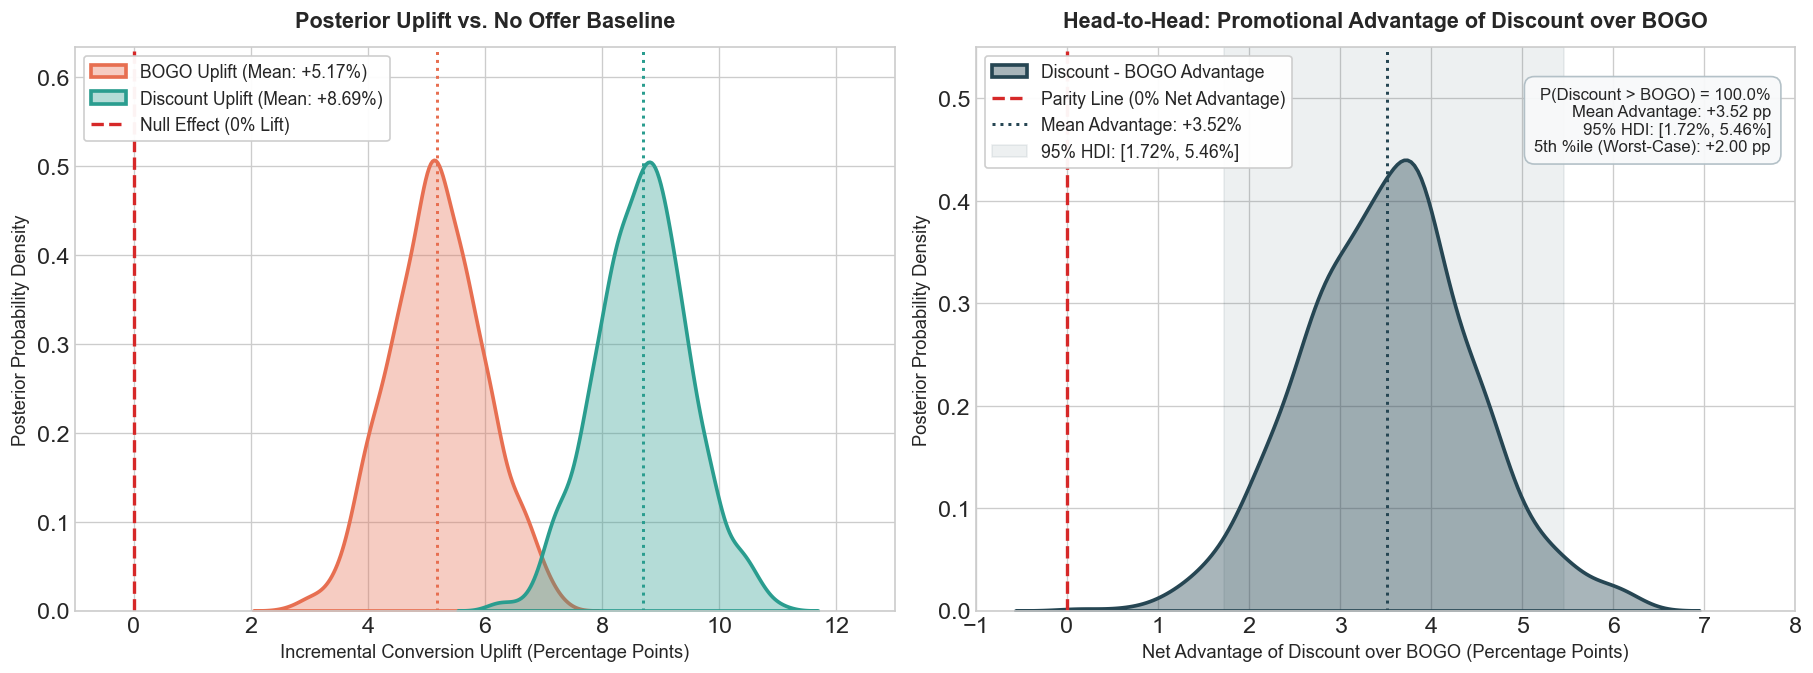

In [8]:
# 5. Visualizing Posterior Uplift Distributions & Head-to-Head Comparison
# High-resolution KDE density plots with vertical headroom, non-overlapping legends, and executive stat callouts.

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5), layout='constrained')

# =========================================================================
# PANEL 1: Uplift vs No Offer Baseline
# =========================================================================
sns.kdeplot(uplift_bogo * 100, fill=True, color='#E76F51', alpha=0.35, linewidth=2.2,
            ax=axes[0], label=f'BOGO Uplift (Mean: +{np.mean(uplift_bogo)*100:.2f}%)')
sns.kdeplot(uplift_discount * 100, fill=True, color='#2A9D8F', alpha=0.35, linewidth=2.2,
            ax=axes[0], label=f'Discount Uplift (Mean: +{np.mean(uplift_discount)*100:.2f}%)')

# Reference benchmarks: Null effect and distribution means
axes[0].axvline(0, color='#D62828', linestyle='--', linewidth=2, label='Null Effect (0% Lift)')
axes[0].axvline(np.mean(uplift_bogo) * 100, color='#E76F51', linestyle=':', linewidth=1.8)
axes[0].axvline(np.mean(uplift_discount) * 100, color='#2A9D8F', linestyle=':', linewidth=1.8)

axes[0].set_title('Posterior Uplift vs. No Offer Baseline', fontsize=13, weight='bold', pad=12)
axes[0].set_xlabel('Incremental Conversion Uplift (Percentage Points)', fontsize=11)
axes[0].set_ylabel('Posterior Probability Density', fontsize=11)
axes[0].set_xlim(-1, 13)
axes[0].margins(y=0.25)  # 25% extra vertical headroom prevents legend crowding
axes[0].legend(loc='upper left', frameon=True, framealpha=0.95, edgecolor='#cccccc', fontsize=10.5)

# =========================================================================
# PANEL 2: Head-to-Head Comparison (Discount vs. BOGO Advantage)
# =========================================================================
uplift_diff_pct = uplift_diff * 100
hdi_diff_low, hdi_diff_high = az.hdi(uplift_diff, hdi_prob=0.95) * 100
prob_diff_pos = np.mean(uplift_diff > 0) * 100

sns.kdeplot(uplift_diff_pct, fill=True, color='#264653', alpha=0.4, linewidth=2.2,
            ax=axes[1], label='Discount - BOGO Advantage')
axes[1].axvline(0, color='#D62828', linestyle='--', linewidth=2, label='Parity Line (0% Net Advantage)')
axes[1].axvline(np.mean(uplift_diff_pct), color='#264653', linestyle=':', linewidth=1.8,
                label=f'Mean Advantage: +{np.mean(uplift_diff_pct):.2f}%')

# Softly shaded 95% Highest Density Interval (HDI) region
axes[1].axvspan(hdi_diff_low, hdi_diff_high, color='#264653', alpha=0.08,
                label=f'95% HDI: [{hdi_diff_low:.2f}%, {hdi_diff_high:.2f}%]')

# Executive Statistics Box placed neatly in upper right with zero overlap
stats_box_text = (
    f'P(Discount > BOGO) = {prob_diff_pos:.1f}%\n'
    f'Mean Advantage: +{np.mean(uplift_diff_pct):.2f} pp\n'
    f'95% HDI: [{hdi_diff_low:.2f}%, {hdi_diff_high:.2f}%]\n'
    f'5th %ile (Worst-Case): +{np.percentile(uplift_diff_pct, 5):.2f} pp'
)
axes[1].text(0.97, 0.93, stats_box_text, transform=axes[1].transAxes, fontsize=10,
             verticalalignment='top', horizontalalignment='right',
             bbox=dict(boxstyle='round,pad=0.6', facecolor='#F8F9FA', edgecolor='#B0BEC5', alpha=0.95))

axes[1].set_title('Head-to-Head: Promotional Advantage of Discount over BOGO', fontsize=13, weight='bold', pad=12)
axes[1].set_xlabel('Net Advantage of Discount over BOGO (Percentage Points)', fontsize=11)
axes[1].set_ylabel('Posterior Probability Density', fontsize=11)
axes[1].set_xlim(-1, 8)
axes[1].margins(y=0.25)
axes[1].legend(loc='upper left', frameon=True, framealpha=0.95, edgecolor='#cccccc', fontsize=10.5)

plt.show()

Customer-level estimated AOV — Mean: $96.21 | Median: $62.28

=== ECONOMIC ANALYSIS & CANNIBALIZATION RISK (100,000 Customers) ===
DISCOUNT CAMPAIGN:
  - Expected Net Profit:       $44,832.77
  - Worst-Case Scenario (5%):  $-17,902.01
  - Risk of Loss (ROI < 0):    12.10%

BOGO CAMPAIGN:
  - Expected Net Profit:       $74,461.46
  - Worst-Case Scenario (5%):  $6,314.19
  - Risk of Loss (ROI < 0):    3.70%


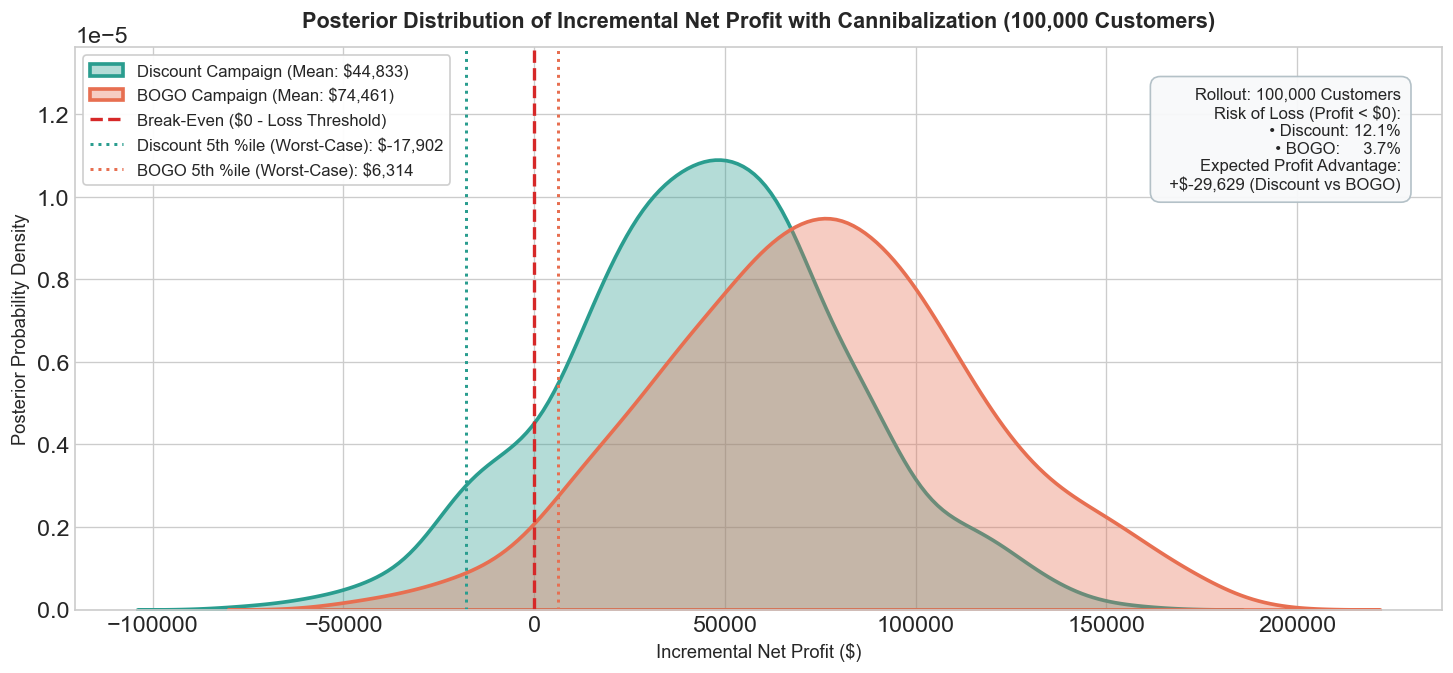

In [83]:
# 6. Rigorous Financial Decision Model: Customer-Specific RFM AOV, Cannibalization & Downside Risk of Loss
# =========================================================================================================

# Step 1: Retrieve unscaled customer monetary history and recency for the representative sample
df_raw = pd.read_csv("data.csv")
recency_raw = df_raw.iloc[sub_indices]["recency"].values
history_raw = df_raw.iloc[sub_indices]["history"].values

# Estimate customer-specific Average Order Value (AOV) via RFM purchase dynamics:
# Estimated annual purchase frequency F = 12 / recency (bounded between 1.0 and 6.0 orders/year)
# Individual AOV_i = history_i / F_i (clipped to realistic retail range: $25 to $300)
est_frequency = np.clip(12.0 / recency_raw, a_min=1.0, a_max=6.0)
aov_user = np.clip(history_raw / est_frequency, a_min=25.0, a_max=300.0)

print(f"Customer-level estimated AOV — Mean: ${np.mean(aov_user):.2f} | Median: ${np.median(aov_user):.2f}")

# Step 2: Commercial Cost and Margin Parameters
MARGIN_RATE = 0.6# Gross margin rate (60% of basket value)
COST_PER_CONTACT = 0.1   # Campaign contact cost ($0.10 per customer targeted)

# Promotional concession per converted customer:
DISCOUNT_RATE = 0.25# 25% direct price discount on converted customer's basket
BOGO_COST_RATE = 0.15  # Cost of free product under BOGO (15% of basket value)

# Step 3: Full Monte Carlo Economic Simulation across MCMC posterior draws:
# For each posterior draw t, compute incremental net profit accounting for:
#   + Gross margin generated by INCREMENTAL conversions (Uplift)
#   - CANNIBALIZATION: promotional discount unnecessarily given to baseline buyers ("Sure Things")
#   - Fixed contact cost of dispatching the promotional campaign

profit_discount_mcmc = np.zeros(n_draws)
profit_bogo_mcmc = np.zeros(n_draws)

# Scaling factor to project economics onto a full campaign rollout of 100,000 customers
TARGET_CAMPAIGN_SIZE = 100000
SCALE = TARGET_CAMPAIGN_SIZE / len(sub_indices)

for t in range(n_draws):
    a = alpha_samples[t]
    b = beta_samples[t]
    xb = X_sub @ b
    
    # Individual conversion probabilities under each scenario
    p_base = expit(a[0] + xb)     # Baseline probability without promo (Sure Things)
    p_bogo = expit(a[1] + xb)     # Probability under BOGO
    p_disc = expit(a[2] + xb)     # Probability under Discount
    
    # --- DISCOUNT CAMPAIGN ECONOMICS ---
    gross_margin = aov_user * MARGIN_RATE
    discount_val = aov_user * DISCOUNT_RATE
    net_margin_disc = gross_margin - discount_val
    
    # Incremental profit = [Incremental Sales * Net Margin] - [Baseline Sales * Cannibalized Discount] - Contact Cost
    new_conv_disc = p_disc - p_base
    profit_disc_i = (new_conv_disc * net_margin_disc) - (p_base * discount_val) - COST_PER_CONTACT
    profit_discount_mcmc[t] = np.sum(profit_disc_i) * SCALE
    
    # --- BOGO CAMPAIGN ECONOMICS ---
    bogo_cost = aov_user * BOGO_COST_RATE
    net_margin_bogo = gross_margin - bogo_cost
    
    new_conv_bogo = p_bogo - p_base
    profit_bogo_i = (new_conv_bogo * net_margin_bogo) - (p_base * bogo_cost) - COST_PER_CONTACT
    profit_bogo_mcmc[t] = np.sum(profit_bogo_i) * SCALE

# Step 4: Financial Summary and Downside Risk Metrics (Risk of Loss: Profit < $0)
prob_loss_disc = np.mean(profit_discount_mcmc < 0) * 100
prob_loss_bogo = np.mean(profit_bogo_mcmc < 0) * 100
worst_profit_disc = np.percentile(profit_discount_mcmc, 5)
worst_profit_bogo = np.percentile(profit_bogo_mcmc, 5)

print(f"\n=== ECONOMIC ANALYSIS & CANNIBALIZATION RISK ({TARGET_CAMPAIGN_SIZE:,} Customers) ===")
print("DISCOUNT CAMPAIGN:")
print(f"  - Expected Net Profit:       ${np.mean(profit_discount_mcmc):,.2f}")
print(f"  - Worst-Case Scenario (5%):  ${worst_profit_disc:,.2f}")
print(f"  - Risk of Loss (ROI < 0):    {prob_loss_disc:.2f}%")

print("\nBOGO CAMPAIGN:")
print(f"  - Expected Net Profit:       ${np.mean(profit_bogo_mcmc):,.2f}")
print(f"  - Worst-Case Scenario (5%):  ${worst_profit_bogo:,.2f}")
print(f"  - Risk of Loss (ROI < 0):    {prob_loss_bogo:.2f}%")

# Step 5: Visualizing Net Profit Posterior Distributions with Cannibalization Penalty
fig, ax = plt.subplots(figsize=(12, 5.5), layout="constrained")

sns.kdeplot(profit_discount_mcmc, fill=True, color="#2A9D8F", alpha=0.35, linewidth=2.2, ax=ax,
            label=f"Discount Campaign (Mean: ${np.mean(profit_discount_mcmc):,.0f})")
sns.kdeplot(profit_bogo_mcmc, fill=True, color="#E76F51", alpha=0.35, linewidth=2.2, ax=ax,
            label=f"BOGO Campaign (Mean: ${np.mean(profit_bogo_mcmc):,.0f})")

# Benchmark lines: Break-even line and worst-case scenarios
ax.axvline(0, color="#D62828", linestyle="--", linewidth=2, label="Break-Even ($0 - Loss Threshold)")
ax.axvline(worst_profit_disc, color="#2A9D8F", linestyle=":", linewidth=1.8,
           label=f"Discount 5th %ile (Worst-Case): ${worst_profit_disc:,.0f}")
ax.axvline(worst_profit_bogo, color="#E76F51", linestyle=":", linewidth=1.8,
           label=f"BOGO 5th %ile (Worst-Case): ${worst_profit_bogo:,.0f}")

# Executive Statistics Box placed in upper right
econ_box_text = (
    f"Rollout: {TARGET_CAMPAIGN_SIZE:,} Customers\n"
    f"Risk of Loss (Profit < $0):\n"
    f"  • Discount: {prob_loss_disc:.1f}%\n"
    f"  • BOGO:     {prob_loss_bogo:.1f}%\n"
    f"Expected Profit Advantage:\n"
    f"  +${np.mean(profit_discount_mcmc) - np.mean(profit_bogo_mcmc):,.0f} (Discount vs BOGO)"
)
ax.text(0.97, 0.93, econ_box_text, transform=ax.transAxes, fontsize=10,
        verticalalignment='top', horizontalalignment='right',
        bbox=dict(boxstyle='round,pad=0.6', facecolor='#F8F9FA', edgecolor='#B0BEC5', alpha=0.95))

ax.set_title(f"Posterior Distribution of Incremental Net Profit with Cannibalization ({TARGET_CAMPAIGN_SIZE:,} Customers)",
             fontsize=13, weight="bold", pad=12)
ax.set_xlabel("Incremental Net Profit ($)", fontsize=11)
ax.set_ylabel("Posterior Probability Density", fontsize=11)
ax.margins(y=0.25)
ax.legend(loc="upper left", frameon=True, framealpha=0.95, edgecolor="#cccccc", fontsize=10)

plt.show()
